# 4 NumPy Basics: Arrays and  Vectorized Computation

In [2]:
import numpy as np

## 4.1 The NumPy ndarray: A Multidimensional Array Object

In [69]:
data=np.array([[1.3,3.4,2.2],[6.0,4.5,7.6]])
data

array([[1.3, 3.4, 2.2],
       [6. , 4.5, 7.6]])

Data shape returns (number of rows, number of columns)

In [70]:
data.shape


(2, 3)

Arrays behave exactly as you would expect under the basic operations

In [71]:
data+data


array([[ 2.6,  6.8,  4.4],
       [12. ,  9. , 15.2]])

In [72]:
3*data

array([[ 3.9, 10.2,  6.6],
       [18. , 13.5, 22.8]])

In [73]:
data.dtype

dtype('float64')

In [74]:
data1=[3.4,4.5,5.6,6.7]

In [75]:
arr1=np.array(data1)

In [76]:
arr1

array([3.4, 4.5, 5.6, 6.7])

In [77]:
data.ndim

2

ndim tells you the number of indices in the "tensor"

In [24]:
arr1.ndim

1

In [25]:
np.zeros((3,4))

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [26]:
my_arr1=np.arange(1_000_000)

In [27]:
my_list1=list(range(1_000_000))

An example of how much faster np.array is than standard python lists. Notice the Jupiter magic commands starting with %

In [33]:
%timeit my_arr=my_arr1*3

272 μs ± 1.37 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [36]:
%timeit my_list2=[x*3 for x in my_list1]

22.1 ms ± 177 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [42]:
np.zeros_like(data)

array([[0., 0., 0.],
       [0., 0., 0.]])

In [44]:
numeric_strings = np.array(["1.25", "-9.6", "42"], dtype=np.bytes_)

In [45]:
numeric_strings.astype(float)

array([ 1.25, -9.6 , 42.  ])

In [47]:
my_arr1>my_arr

array([False, False, False, ..., False, False, False], shape=(1000000,))

In [48]:
arr=np.arange(15)

In [49]:
arr

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [50]:
arr[3:6]

array([3, 4, 5])

In [51]:
arr[4:6]=90

In [52]:
arr

array([ 0,  1,  2,  3, 90, 90,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [53]:
arr2d=np.arange(10,10)

In [54]:
arr2d

array([], dtype=int64)

In [55]:
arr2d.shape

(0,)

In [56]:
arr2d=np.array([[1,2,3],[4,5,6],[7,8,9]])

In [58]:
arr2d.ndim

2

In [61]:
arr2d[2]=23

In [62]:
arr2d

array([[ 1,  2,  3],
       [ 4,  5,  6],
       [23, 23, 23]])

In [65]:
arr2d[0,2]

np.int64(3)

In [66]:
int(arr2d[0,2])

3

In [68]:
arr2d[:1,:2]

array([[1, 2]])

An interesting way of indexing is by using arrays of booleans

In [79]:
names = np.array(["Bob", "Joe", "Will", "Bob", "Will", "Joe", "Joe"])

In [80]:
data = np.array([[4, 7], [0, 2], [-5, 6], [0, 0], [1, 2], [-12, -4], [3, 4]])

In [83]:
names=='Bob'

array([ True, False, False,  True, False, False, False])

Only the entries corresponding to True will be returned

In [84]:
data[names=='Bob']

array([[4, 7],
       [0, 0]])

You can really use the boolean indexing as if it was a canonical way od indexing

In [85]:
data[names == "Bob", 1:]

array([[7],
       [0]])

In [86]:
data[names == "Bob", 1]

array([7, 0])

In [87]:
data[~(names == "Bob")]

array([[  0,   2],
       [ -5,   6],
       [  1,   2],
       [-12,  -4],
       [  3,   4]])

In [88]:
mask = (names == "Bob") | (names == "Will")

In [89]:
data[mask]

array([[ 4,  7],
       [-5,  6],
       [ 0,  0],
       [ 1,  2]])

**NOTE**: Selecting data from an array by Boolean indexing and assigning the result to a new variable always creates a copy of the data, even if the returned array is unchanged.

You can also assign values using booleans

In [90]:
data[data < 0] = 0

In [91]:
data

array([[4, 7],
       [0, 2],
       [0, 6],
       [0, 0],
       [1, 2],
       [0, 0],
       [3, 4]])

In [92]:
data[names != "Joe"] = 7

In [93]:
data

array([[7, 7],
       [0, 2],
       [7, 7],
       [7, 7],
       [7, 7],
       [0, 0],
       [3, 4]])

There is also *fancy indexing*, namely indexing using arrinteger arrays (or lists)

In [94]:
arr = np.arange(32).reshape((8, 4))

In [95]:
arr

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23],
       [24, 25, 26, 27],
       [28, 29, 30, 31]])

In [96]:
arr[[4, 3, 0, 6]]

array([[16, 17, 18, 19],
       [12, 13, 14, 15],
       [ 0,  1,  2,  3],
       [24, 25, 26, 27]])

In [97]:
arr[[1, 5, 7, 2], [0, 3, 1, 2]]

array([ 4, 23, 29, 10])

Fancy indexing in this case is taking each row and mixing the columns according to the order in the second list.

In [98]:
arr[[1, 5, 7, 2]][:, [0, 3, 1, 2]]

array([[ 4,  7,  5,  6],
       [20, 23, 21, 22],
       [28, 31, 29, 30],
       [ 8, 11,  9, 10]])

You can transpose matrices with .T

In [99]:
arr1 = np.arange(15).reshape((3, 5))

In [100]:
arr1

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [101]:
arr1.T

array([[ 0,  5, 10],
       [ 1,  6, 11],
       [ 2,  7, 12],
       [ 3,  8, 13],
       [ 4,  9, 14]])

You can do the inner product using np.dot or with the operator @

In [102]:
np.dot(arr1.T,arr1)

array([[125, 140, 155, 170, 185],
       [140, 158, 176, 194, 212],
       [155, 176, 197, 218, 239],
       [170, 194, 218, 242, 266],
       [185, 212, 239, 266, 293]])

In [104]:
arr1.T@arr1

array([[125, 140, 155, 170, 185],
       [140, 158, 176, 194, 212],
       [155, 176, 197, 218, 239],
       [170, 194, 218, 242, 266],
       [185, 212, 239, 266, 293]])

You can swap a particular pair of indices using swapaxes (in this case we only have 2 so it is like transposing)

In [105]:
arr1.swapaxes(0, 1)

array([[ 0,  5, 10],
       [ 1,  6, 11],
       [ 2,  7, 12],
       [ 3,  8, 13],
       [ 4,  9, 14]])

## 4.2 Pseudorandom Number Generation

You can efficiently sample values from a distribution with the `random` module and then using the appropriate method

In [3]:
samples = np.random.standard_normal(size=(5, 5))

In [4]:
samples

array([[-0.32935762,  1.67523976,  0.95215913, -0.39933653,  2.10129677],
       [ 1.15993745, -0.36876511, -1.3388526 , -0.20715023,  0.14326249],
       [-0.72300192, -0.64576165, -0.51322978, -1.93075322,  1.28477695],
       [-0.50477044, -0.04234358, -0.1500933 , -0.96385943,  0.5216626 ],
       [ 1.08959202,  0.71441442,  0.61000684,  0.30337693,  0.1567407 ]])

The standard random library in Python samples one value at a time

In [5]:
from random import normalvariate

In [6]:
N = 1_000_000

In [7]:
%timeit samples = [normalvariate(0, 1) for _ in range(N)]

258 ms ± 4.91 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [8]:
%timeit np.random.standard_normal(N)

10.6 ms ± 114 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


It is possible to use personalized random generators. There are a few details that I will leave to when I will need to use this explicitly.

## 4.3 Universal Functions: Fast Element-Wise Array Functions

A universal function, or `ufunc`, is a function that performs element-wise operations on data in ndarrays. You can think of them as fast vectorized wrappers for simple functions that take one or more scalar values and produce one or more scalar results.

**Unary** functions take only one array as an argument

In [9]:
arr = np.arange(10)

In [10]:
np.sqrt(arr)

array([0.        , 1.        , 1.41421356, 1.73205081, 2.        ,
       2.23606798, 2.44948974, 2.64575131, 2.82842712, 3.        ])

In [11]:
np.exp(arr)

array([1.00000000e+00, 2.71828183e+00, 7.38905610e+00, 2.00855369e+01,
       5.45981500e+01, 1.48413159e+02, 4.03428793e+02, 1.09663316e+03,
       2.98095799e+03, 8.10308393e+03])

**Binary** functions take two. Here `rng` illustrates how to set a particular random number generator and then set it to the standard one.

In [13]:
rng = np.random.default_rng(seed=12345)
x = rng.standard_normal(8)
y = rng.standard_normal(8)

In [14]:
print(x)
print(y)
np.maximum(x,y)

[-1.42382504  1.26372846 -0.87066174 -0.25917323 -0.07534331 -0.74088465
 -1.3677927   0.6488928 ]
[ 0.36105811 -1.95286306  2.34740965  0.96849691 -0.75938718  0.90219827
 -0.46695317 -0.06068952]


array([ 0.36105811,  1.26372846,  2.34740965,  0.96849691, -0.07534331,
        0.90219827, -0.46695317,  0.6488928 ])

A `ufunc` can return multiple arrays. `numpy.modf` is one example: a vectorized version of the built-in Python `math.modf`, it returns the fractional and integral parts of a floating-point array:

In [15]:
arr = rng.standard_normal(7) * 5

In [16]:
arr

array([ 3.94422172, -6.28334067,  2.87928757,  6.99489497,  6.6114903 ,
       -1.49849258,  4.51459671])

In [18]:
remainder, whole_part = np.modf(arr)

In [19]:
remainder

array([ 0.94422172, -0.28334067,  0.87928757,  0.99489497,  0.6114903 ,
       -0.49849258,  0.51459671])

In [20]:
whole_part

array([ 3., -6.,  2.,  6.,  6., -1.,  4.])

Ufuncs accept an optional out argument that allows them to assign their results into an existing array rather than create a new one:

In [21]:
out = np.zeros_like(arr)

In [22]:
out

array([0., 0., 0., 0., 0., 0., 0.])

In [24]:
arr

array([ 3.94422172, -6.28334067,  2.87928757,  6.99489497,  6.6114903 ,
       -1.49849258,  4.51459671])

In [23]:
np.add(arr, 1)

array([ 4.94422172, -5.28334067,  3.87928757,  7.99489497,  7.6114903 ,
       -0.49849258,  5.51459671])

In [25]:
np.add(arr, 1, out=out)

array([ 4.94422172, -5.28334067,  3.87928757,  7.99489497,  7.6114903 ,
       -0.49849258,  5.51459671])

By using the optional argument above, the `out` array has been updated 

In [26]:
out

array([ 4.94422172, -5.28334067,  3.87928757,  7.99489497,  7.6114903 ,
       -0.49849258,  5.51459671])

## 4.4 Array-Oriented Programming with Arrays

Vectorization, vectorization, vectorization

In [44]:
points = np.arange(-5, 5, 0.01)

In [45]:
points

array([-5.0000000e+00, -4.9900000e+00, -4.9800000e+00, -4.9700000e+00,
       -4.9600000e+00, -4.9500000e+00, -4.9400000e+00, -4.9300000e+00,
       -4.9200000e+00, -4.9100000e+00, -4.9000000e+00, -4.8900000e+00,
       -4.8800000e+00, -4.8700000e+00, -4.8600000e+00, -4.8500000e+00,
       -4.8400000e+00, -4.8300000e+00, -4.8200000e+00, -4.8100000e+00,
       -4.8000000e+00, -4.7900000e+00, -4.7800000e+00, -4.7700000e+00,
       -4.7600000e+00, -4.7500000e+00, -4.7400000e+00, -4.7300000e+00,
       -4.7200000e+00, -4.7100000e+00, -4.7000000e+00, -4.6900000e+00,
       -4.6800000e+00, -4.6700000e+00, -4.6600000e+00, -4.6500000e+00,
       -4.6400000e+00, -4.6300000e+00, -4.6200000e+00, -4.6100000e+00,
       -4.6000000e+00, -4.5900000e+00, -4.5800000e+00, -4.5700000e+00,
       -4.5600000e+00, -4.5500000e+00, -4.5400000e+00, -4.5300000e+00,
       -4.5200000e+00, -4.5100000e+00, -4.5000000e+00, -4.4900000e+00,
       -4.4800000e+00, -4.4700000e+00, -4.4600000e+00, -4.4500000e+00,
      

In [46]:
xs, ys = np.meshgrid(points, points)

In [47]:
xs

array([[-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       ...,
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99]],
      shape=(1000, 1000))

In [37]:
ys

array([[-1.00000000e+00, -1.00000000e+00, -1.00000000e+00,
        -1.00000000e+00, -1.00000000e+00, -1.00000000e+00,
        -1.00000000e+00, -1.00000000e+00, -1.00000000e+00,
        -1.00000000e+00, -1.00000000e+00, -1.00000000e+00,
        -1.00000000e+00, -1.00000000e+00, -1.00000000e+00,
        -1.00000000e+00, -1.00000000e+00, -1.00000000e+00,
        -1.00000000e+00, -1.00000000e+00],
       [-9.00000000e-01, -9.00000000e-01, -9.00000000e-01,
        -9.00000000e-01, -9.00000000e-01, -9.00000000e-01,
        -9.00000000e-01, -9.00000000e-01, -9.00000000e-01,
        -9.00000000e-01, -9.00000000e-01, -9.00000000e-01,
        -9.00000000e-01, -9.00000000e-01, -9.00000000e-01,
        -9.00000000e-01, -9.00000000e-01, -9.00000000e-01,
        -9.00000000e-01, -9.00000000e-01],
       [-8.00000000e-01, -8.00000000e-01, -8.00000000e-01,
        -8.00000000e-01, -8.00000000e-01, -8.00000000e-01,
        -8.00000000e-01, -8.00000000e-01, -8.00000000e-01,
        -8.00000000e-01, -8.0

In [48]:
z = np.sqrt(xs ** 2 + ys ** 2)

In [50]:
%pip install matplotlib
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 23.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 21.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 9.6 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.


Text(0.5, 1.0, 'Image plot of $\\sqrt{x^2 + y^2}$ for a grid of values')

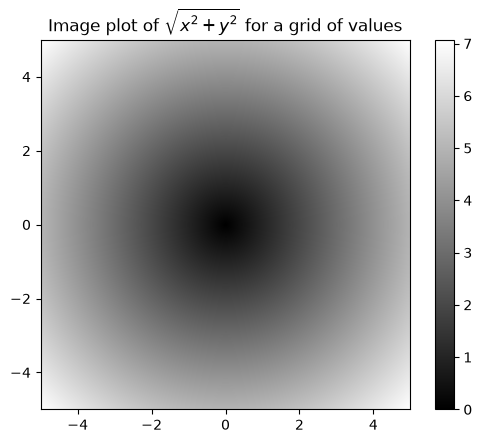

In [61]:
plt.imshow(z, cmap=plt.cm.gray, extent=[-5, 5, -5, 5])
plt.colorbar()
plt.title(r"Image plot of $\sqrt{x^2 + y^2}$ for a grid of values")

In [62]:
plt.close("all")

### Expressing Conditional Logic as Array Operations

The `numpy.where` function is a vectorized version of the ternary expression x if  condition else y. Suppose we wanted to take a value from xarr whenever the corresponding value in  cond is True, and otherwise take the value from yarr

In [63]:
xarr = np.array([1.1, 1.2, 1.3, 1.4, 1.5])

In [64]:
yarr=xarr+1

In [65]:
yarr

array([2.1, 2.2, 2.3, 2.4, 2.5])

In [66]:
cond = np.array([True, False, True, True, False])

A list comprehension doing  this might look like:

In [67]:
result = [(x if c else y) for x, y, c in zip(xarr, yarr, cond)]

In [71]:
result

[np.float64(1.1),
 np.float64(2.2),
 np.float64(1.3),
 np.float64(1.4),
 np.float64(2.5)]

Problems: 
- not be very fast for large arrays (because all the work is being done in interpreted Python code). 
- will not work with multidimensional arrays.

In [72]:
result = np.where(cond, xarr, yarr)

In [73]:
result

array([1.1, 2.2, 1.3, 1.4, 2.5])

Suppose you had a matrix of randomly generated data and you wanted to replace all positive values with 2 and all negative values with –2.

In [74]:
arr=np.random.standard_normal((4,4))

In [75]:
arr

array([[-1.28847355, -0.9885063 , -1.6221521 , -1.1566411 ],
       [-0.33942311, -0.10441453,  0.59269246, -1.3051338 ],
       [ 0.3207087 ,  2.45714469,  0.11873533,  0.35504781],
       [ 0.61276833,  0.55964931, -0.24759767,  0.77049939]])

In [76]:
cond2=arr>0

In [77]:
cond2

array([[False, False, False, False],
       [False, False,  True, False],
       [ True,  True,  True,  True],
       [ True,  True, False,  True]])

In [78]:
arr2=np.where(cond2, 2,-2)

In [79]:
arr2

array([[-2, -2, -2, -2],
       [-2, -2,  2, -2],
       [ 2,  2,  2,  2],
       [ 2,  2, -2,  2]])

You can also use scalars and arrays simultaneously in `where`, in case, for example, you wanted to modify one thing and retain the previous values if the condition is not satisfied

In [ ]:
np.where(arr > 0, 2, arr)

array([[-1.28847355, -0.9885063 , -1.6221521 , -1.1566411 ],
       [-0.33942311, -0.10441453,  2.        , -1.3051338 ],
       [ 2.        ,  2.        ,  2.        ,  2.        ],
       [ 2.        ,  2.        , -0.24759767,  2.        ]])

### Mathematical and Statistical Methods

In [81]:
arr = rng.standard_normal((5, 4))

In [82]:
arr

array([[-1.62158273, -0.15818926,  0.44948393, -1.34360107],
       [-0.08168759,  1.72473993,  2.61815943,  0.77736134],
       [ 0.8286332 , -0.95898831, -1.20938829, -1.41229201],
       [ 0.54154683,  0.7519394 , -0.65876032, -1.22867499],
       [ 0.25755777,  0.31290292, -0.13081169,  1.26998312]])

In [83]:
arr.mean()

np.float64(0.03641657980011391)

In [85]:
np.mean(arr)

np.float64(0.03641657980011391)

In [86]:
arr.sum()

np.float64(0.7283315960022783)

`axis=0` means same column different rows, `axis=1` means same column different rows

In [89]:
arr.sum(axis=0)

array([-0.07553253,  1.67240467,  1.06868306, -1.93722361])

In [90]:
arr.sum(axis=1)

array([-2.67388914,  5.03857311, -2.75203542, -0.59394908,  1.70963212])

In [91]:
arr2=np.arange(10)

In [92]:
arr2.cumsum()

array([ 0,  1,  3,  6, 10, 15, 21, 28, 36, 45])

In multidimensional arrays, accumulation functions like cumsum return an array of the same size but with the partial aggregates computed along the indicated axis according to each lower dimensional slice:

In [93]:
arr3=np.arange(9).reshape((3,3))

In [96]:
arr3

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

In [94]:
arr3.cumsum(axis=0)

array([[ 0,  1,  2],
       [ 3,  5,  7],
       [ 9, 12, 15]])

In [95]:
arr3.cumsum(axis=1)

array([[ 0,  1,  3],
       [ 3,  7, 12],
       [ 6, 13, 21]])

In [98]:
arr3.argmax()

np.int64(8)

### Methods for Boolean Arrays

In [113]:
arr = rng.standard_normal(100)

In [114]:
(arr>0).sum()

np.int64(51)

In [115]:
(arr<=0).sum()

np.int64(49)

In [116]:
bools = np.array([False, False, True, False])

In [117]:
bools.any()

np.True_

In [118]:
bools.all()

np.False_

### Sorting

Sorting in place

In [119]:
arr.sort()

In [120]:
arr

array([-2.72241610e+00, -1.99585661e+00, -1.97524767e+00, -1.85333593e+00,
       -1.79571318e+00, -1.64041784e+00, -1.60270159e+00, -1.53815403e+00,
       -1.38835995e+00, -1.26162378e+00, -1.15452958e+00, -1.14907382e+00,
       -1.12296158e+00, -1.10821447e+00, -1.09542531e+00, -1.06580785e+00,
       -1.06364272e+00, -9.65478907e-01, -9.07382457e-01, -8.57258824e-01,
       -8.15814967e-01, -8.11886879e-01, -7.95017456e-01, -7.75896101e-01,
       -7.48643984e-01, -7.01690809e-01, -6.53505648e-01, -6.23612134e-01,
       -5.71032902e-01, -4.28074443e-01, -4.25150050e-01, -4.14853761e-01,
       -3.59479647e-01, -3.17391946e-01, -2.75171567e-01, -2.52873345e-01,
       -2.44552532e-01, -2.23638926e-01, -1.81472740e-01, -1.58476860e-01,
       -1.55247617e-01, -1.24341928e-01, -1.10418688e-01, -9.84250348e-02,
       -9.29624577e-02, -7.12708062e-02, -6.61508890e-02, -6.19046857e-02,
       -2.55381724e-02,  7.85525063e-04,  7.14569494e-03,  3.57428624e-02,
        5.30566461e-02,  

In [141]:
arr2=np.arange(9).reshape((3,3))

In [142]:
arr2

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

In [144]:
arr2.sort(axis=0)

In [145]:
arr2

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

In [138]:
arr2.sort(axis=1)

### Unique and Other Set Logic

In [147]:
names = np.array(["Bob", "Will", "Joe", "Bob", "Will", "Joe", "Joe"])

In [150]:
np.unique(names)

array(['Bob', 'Joe', 'Will'], dtype='<U4')

In [151]:
values = np.array([6, 0, 0, 3, 2, 5, 6])

In [153]:
np.isin(values, [2, 3, 6])

array([ True, False, False,  True,  True, False,  True])

## 4.6 Linear Algebra

`x.dot(y)` is equivalent to `np.dot(x, y)`. `numpy.linalg` has a standard set of matrix decompositions and things like inverse  and determinant.

In [155]:
from numpy.linalg import inv, qr

In [156]:
X = rng.standard_normal((5, 5))

In [157]:
mat = X.T @ X

In [158]:
inv(mat)

array([[ 9.74082856e-01, -1.73052738e-01,  2.93422455e-03,
        -1.85862713e+00,  9.51829476e-01],
       [-1.73052738e-01,  9.55405647e+00,  2.87114972e+00,
        -3.61729352e+01,  7.91555625e+00],
       [ 2.93422455e-03,  2.87114972e+00,  9.98118491e-01,
        -1.13161047e+01,  2.68454296e+00],
       [-1.85862713e+00, -3.61729352e+01, -1.13161047e+01,
         1.49448961e+02, -3.57923561e+01],
       [ 9.51829476e-01,  7.91555625e+00,  2.68454296e+00,
        -3.57923561e+01,  1.03643395e+01]])

In [159]:
mat @ inv(mat)

array([[ 1.00000000e+00, -1.79747830e-15,  5.09650539e-17,
        -1.18397628e-15,  2.66387088e-16],
       [-3.22859081e-16,  1.00000000e+00,  7.03856481e-16,
         1.47404364e-14, -1.73457082e-15],
       [ 1.01889127e-16,  6.80830560e-15,  1.00000000e+00,
        -1.76486134e-14,  4.68059888e-15],
       [-8.30047423e-17, -1.52774101e-15,  2.24869907e-16,
         1.00000000e+00, -8.53632256e-16],
       [ 5.15159695e-18,  1.37081242e-15,  3.30342371e-16,
         4.41669718e-15,  1.00000000e+00]])

In [164]:
np.linalg.eig(mat)[0]

array([9.90504944e+00+0.j, 5.17373478e+00+0.j, 1.27614543e+00+0.j,
       3.92859273e-01+0.j, 5.96245093e-03+0.j])

## 4.7 Example: Random Walks

You might make the observation that walk is the cumulative sum of the random steps and could be evaluated as an array expression. Thus, I use the numpy.random module to draw 1,000 coin flips at once, set these to 1 and –1, and compute the cumulative sum:

In [169]:
walk=rng.standard_normal(1000)

In [170]:
steps=np.where(walk>0, 1, -1)

In [171]:
random_walk=steps.cumsum()

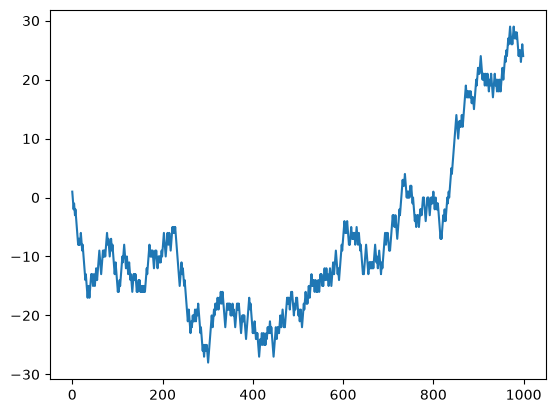

In [172]:
plt.plot(random_walk)

In [174]:
plt.close()

In [175]:
random_walk.min()

np.int64(-28)

In [176]:
random_walk.max()

np.int64(29)

First step the walk crossed the value 10, you first create an array of booleans and then use argmax to find the first occurence of true.

In [177]:
(random_walk>=10).argmax()

np.int64(847)

### Simulating Many Random Walks at Once

If your goal was to simulate many random walks, say five thousand of them, you can generate all of the random walks with minor modifications to the preceding code. If passed a 2-tuple, the numpy.random functions will generate a two-dimensional array of draws, and we can compute the cumulative sum for each row to compute all five thousand random walks in one shot:

In [180]:
rng=np.random.default_rng(34)

In [186]:
nwalks=5000
nsteps=1000
draws=rng.integers(0,2,(nwalks, nsteps))

In [187]:
draws

array([[0, 1, 1, ..., 0, 0, 1],
       [0, 1, 0, ..., 1, 0, 1],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 0, 0, ..., 1, 1, 0],
       [0, 1, 1, ..., 1, 0, 1],
       [1, 1, 0, ..., 0, 0, 1]], shape=(5000, 1000))

In [188]:
steps=np.where(draws>0, draws,-1)

In [189]:
steps

array([[-1,  1,  1, ..., -1, -1,  1],
       [-1,  1, -1, ...,  1, -1,  1],
       [-1, -1, -1, ..., -1, -1, -1],
       ...,
       [ 1, -1, -1, ...,  1,  1, -1],
       [-1,  1,  1, ...,  1, -1,  1],
       [ 1,  1, -1, ..., -1, -1,  1]], shape=(5000, 1000))

In [191]:
walks=steps.cumsum(axis=1)

In [192]:
walks.max()

np.int64(154)

In [193]:
walks.min()

np.int64(-136)

Out of these walks, let’s compute the minimum crossing time to 30 or –30. This is slightly tricky because not all 5,000 of them reach 30. We can check this using the any method

In [197]:
hits30 = (np.abs(walks) >= 30).any(axis=1)

How many actually hit -30 or +30?

In [198]:
hits30.sum()

np.int64(3395)

In [202]:
crossing_times=(np.abs(walks[hits30]>=30)).argmax(axis=1)

In [204]:
crossing_times.mean()

np.float64(249.34491899852725)